In [2]:
#Import necessary packages
import xarray as xr
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression
from matplotlib.lines import Line2D

/lustre/storeB/project/fou/hi/foccus/.venv/lib64/python3.11/site-packages/xarray/groupers.py:487: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


ValueError: x and y must have same first dimension, but have shapes (12758648,) and (22074892,)

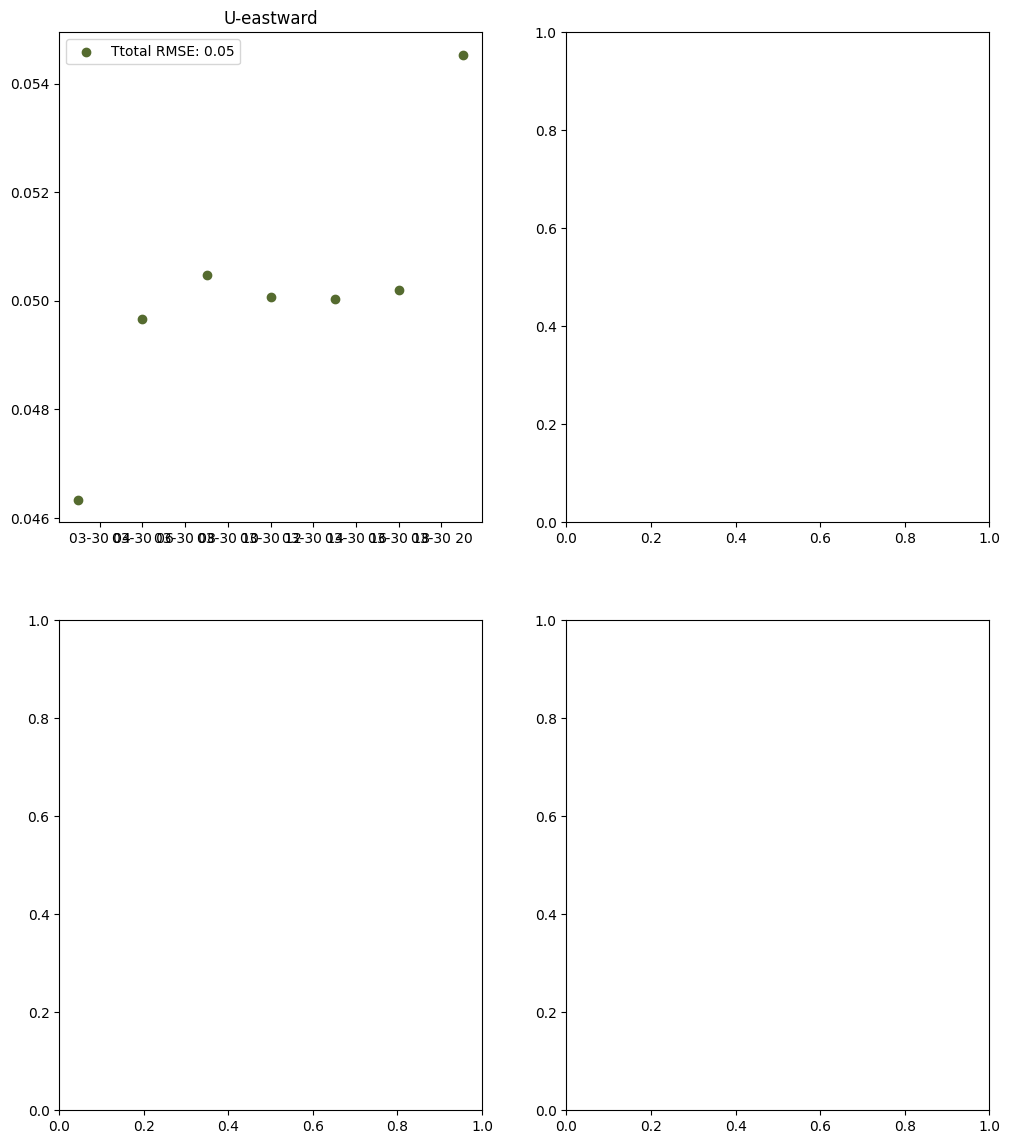

In [13]:
truth = xr.open_dataset('/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240330.nc').isel(s_rho = -1)
predicted = xr.open_dataset('/lustre/storeB/project/fou/hi/foccus/malene/run-anemoi-ocean/ppi/external_checkpoint_inference/Inference_res/lr_v2/lr3-5e-04-st200-se42/2024-03-30_24h_18d28_e011_s049990.nc')

#Resample truth datastep 3hrs
truth_resampled = truth.resample(time = '3H').mean()
truth_rename = truth_resampled.rename({'X' : 'Y', 'Y' : 'X'})

#Remove first time step of datasets and align shapes (24hr range)
truth_skip_timestep = truth_rename.isel(time = slice(1,None))
predicted_skip_timestep = predicted.isel(time=slice(1,-1))

#select out variable values - thinking temperature, salinity, u and v
target_vars_norkyst = ['u_eastward', 'v_northward', 'temperature', 'salinity']
target_vars_havbris = ['u_eastward_0', 'v_northward_0', 'temperature_0', 'salinity_0']

rmse_by_timestep = {}
rmse_total = {}
regression_lines = {}

for nk_var, hb_var in zip(target_vars_norkyst, target_vars_havbris):

    nk_data = truth_skip_timestep[nk_var]
    hb_data = predicted_skip_timestep[hb_var]

    #calculating MSE and RMSE using groupby for each timestep
    error = (nk_data - hb_data)
    mse_by_timestep = (error **2).groupby('time').mean(['Y', 'X'])
    rmse_by_timestep[nk_var] = np.sqrt(mse_by_timestep)

    #Also calculate total RMSE for period - will use sklearn for efficient calculation
    #first filter out nans 
    mask = ~np.isnan(nk_data) & ~np.isnan(hb_data)
    rmse_total[nk_var] = root_mean_squared_error(nk_data.values[mask], hb_data.values[mask])

    #make regression lines for each variable predictions
    nk_reg = nk_data.values[mask].flatten()
    hb_reg = hb_data.values[mask].flatten()

    model = LinearRegression()
    model.fit(hb_reg.reshape(-1,1), nk_reg)
    regression_lines[nk_var] = model.predict(hb_reg.reshape(-1,1))

fig, ax = plt.subplots(2,2, figsize = (12,14))

labels = ['U-eastward', 'V-northward', 'Temperature', 'Salinity']
for i, (nk_var, hb_var) in enumerate(zip(target_vars_norkyst, target_vars_havbris)):
    row, col = divmod(i,2)
    ax[row, col].set_title(labels[i])
    ax[row, col].scatter(rmse_by_timestep[nk_var].time, rmse_by_timestep[nk_var], label = 'RMSE per timestep', color = 'darkolivegreen')
    ax[row, col].legend([f'Ttotal RMSE: {rmse_total[nk_var]:.2f}'])
    ax[row, col].plot(hb_reg, regression_lines[nk_var], color = 'm', label = 'Regression Line')
    plt.setp(ax[row,col].xaxis.get_majorticklabels(), rotation =45)
plt.show()